# Grad-CAM localization analysis

All radio RGB cutouts and Grad-CAM maps are **resized to 150×150** before metrics (see `cam_attention_metrics.py`).

- **Source mask (pseudo–ground truth):** pixels with grayscale flux above **mean + n·σ** of the patch (default **3σ**).
- **CAM activation:** top fraction of pixels by heatmap value; PR curves sweep that fraction (`CAM_TOP_FRACS` in the module).

Data layout: `all_cam_output/byol/<run>/grad_cam_*/cam_npz/*.npz` and `all_cam_output/supervised_gradcam/<run>/...`.

In [ ]:
# import importlib
# import os

# import matplotlib.pyplot as plt
# import numpy as np

# import cam_attention_metrics as cam

# importlib.reload(cam)


# BASE = "/path/to/rgc/all_cam_output"
# # Cache uses cam_attention_metrics logic; bump version when logic changes
# CACHE_CSV = "/path/to/rgc/attention_metrics_cache_v3.csv"

# # Set to a small int for a quick test; None = all ~24k npz per tree walk order
# LIMIT = None
# N_SIGMA = 3.0

# if os.path.isfile(CACHE_CSV):
#     print("Loading", CACHE_CSV)
#     rows = cam.load_rows_csv(CACHE_CSV)
# else:
#     print("Computing metrics (first run can take several minutes)...")
#     rows = cam.build_table(BASE, limit=LIMIT, n_sigma=N_SIGMA, progress=True)
#     cam.save_rows_csv(rows, CACHE_CSV)
#     print("Wrote", CACHE_CSV, "rows:", len(rows))

# print("rows:", len(rows))
# gk = sorted({r["group_key"] for r in rows})
# print("groups:", len(gk))
# for s in gk[:8]:
#     print(" ", s)
# if len(gk) > 8:
#     print("  ...")
import importlib
import os

import matplotlib.pyplot as plt
import numpy as np

import cam_attention_metrics as cam

importlib.reload(cam)


BASE = "/path/to/rgc/all_cam_output"
# ↓ bumped to v3 because CSV_FIELDS now includes "nmi"
CACHE_CSV = "/path/to/rgc/attention_metrics_cache.csv"

LIMIT = None
N_SIGMA = 3.0

if os.path.isfile(CACHE_CSV):
    print("Loading", CACHE_CSV)
    rows = cam.load_rows_csv(CACHE_CSV)
else:
    print("Computing metrics (first run can take several minutes)...")
    rows = cam.builfor the heat maps, d_table(BASE, limit=LIMIT, n_sigma=N_SIGMA, progress=True)
    cam.save_rows_csv(rows, CACHE_CSV)
    print("Wrote", CACHE_CSV, "rows:", len(rows))

print("rows:", len(rows))
gk = sorted({r["group_key"] for r in rows})
print("groups:", len(gk))
for s in gk[:8]:
    print(" ", s)
if len(gk) > 8:
    print("  ...")

Loading /path/to/rgc/attention_metrics_cache.csv
rows: 24720
groups: 12
  BYOL · no spurious
  BYOL · spurious
  ConvNeXt-B · no spurious
  ConvNeXt-B · spurious
  ResNet50 · no spurious
  ResNet50 · spurious
  Swin-B · no spurious
  Swin-B · spurious
  ...


In [11]:
# Fixed legend serials (M1..M6) and high-contrast colors
# Note: `arch` here is the display name produced by `cam_attention_metrics.parse_npz_path()`.
MODEL_SERIAL = {
    "ConvNeXt-B": "M1",
    "BYOL": "M2",
    "VGG16": "M3",
    "Swin-B": "M4",
    "ResNet50": "M5",
    "ViT-B/16": "M6",
}

# Worst -> best combined accuracy
MODEL_COLOR = {
    "ViT-B/16": "#ff3b30",
    "ResNet50": "#ff9500",
    "Swin-B": "#ffcc00",
    "VGG16": "#34c759",
    "BYOL": "#0a84ff",
    "ConvNeXt-B": "#bf5af2",
}

# Legend order (top -> bottom): M1, M2, ..., M6
MODEL_ORDER_ARCH = ["ConvNeXt-B", "BYOL", "VGG16", "Swin-B", "ResNet50", "ViT-B/16"]

# Replace the fixed “top 20%” with a variable
SINGLE_CAM_FRAC = 0.20


def group_to_arch(group_key: str) -> str:
    # group_key looks like: "<arch> · <spurious/no spurious>"
    return group_key.split(" · ")[0].strip()



## 1. Localization precision–recall (CAM threshold sweep)

For each **top fraction** of CAM activation, mean precision and recall vs the **3σ radio mask**, averaged over all sources in that group. Varying the CAM threshold traces a PR curve; diffuse models tend toward high recall / low precision at generous thresholds.

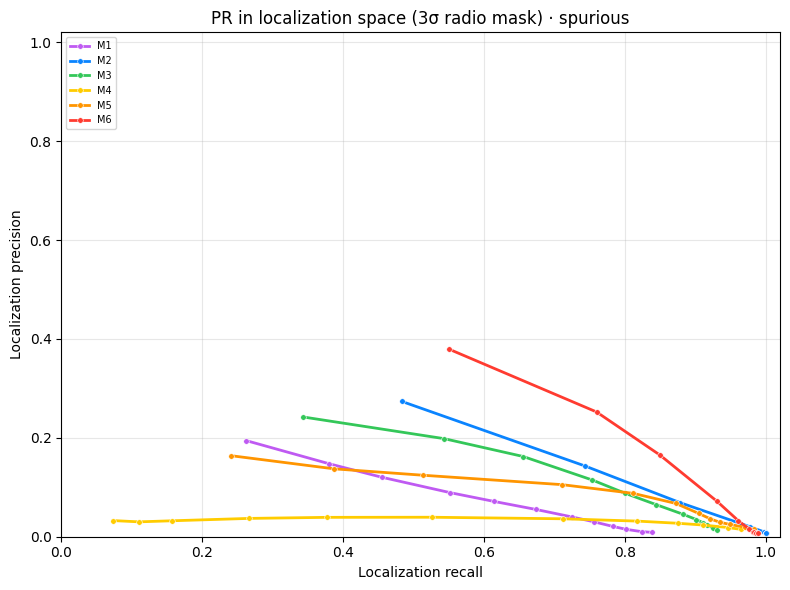

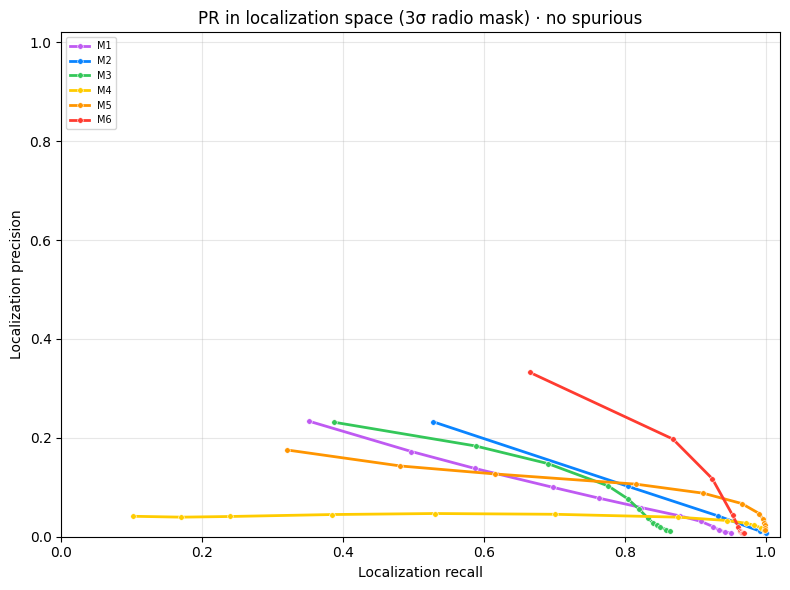

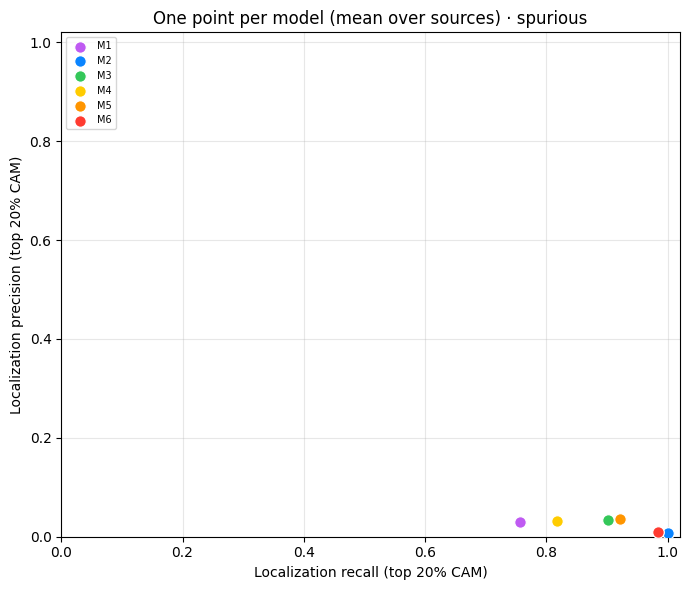

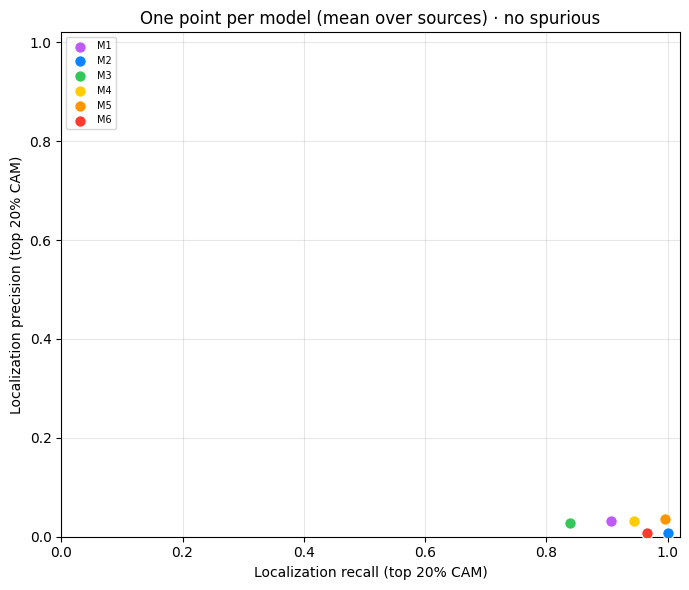

In [12]:
rows_sp = [r for r in rows if r["spurious"]]
rows_nosp = [r for r in rows if not r["spurious"]]


def _plot_pr_curves(rows_subset, sp_label: str):
    curves = cam.pr_curve_by_group(rows_subset)
    arch_curves: dict[str, tuple[np.ndarray, np.ndarray]] = {}
    for gk, (R, P) in curves.items():
        arch = group_to_arch(gk)
        arch_curves[arch] = (R, P)

    fig, ax = plt.subplots(figsize=(8, 6))
    for arch in MODEL_ORDER_ARCH:
        if arch not in arch_curves:
            continue
        R, P = arch_curves[arch]
        ax.plot(
            R,
            P,
            "-o",
            ms=4,
            lw=2.0,
            color=MODEL_COLOR[arch],
            label=MODEL_SERIAL[arch],
            mec="white",
            mew=0.4,
        )

    ax.set_xlabel("Localization recall")
    ax.set_ylabel("Localization precision")
    ax.set_title(f"PR in localization space (3σ radio mask) · {sp_label}")
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.show()


_plot_pr_curves(rows_sp, "spurious")
_plot_pr_curves(rows_nosp, "no spurious")



def _plot_pr_scatter(rows_subset, sp_label: str):
    curves = cam.pr_curve_by_group(rows_subset)
    # Map: arch -> (R_mean, P_mean)
    arch_curves: dict[str, tuple[np.ndarray, np.ndarray]] = {}
    for gk, (R, P) in curves.items():
        arch = group_to_arch(gk)
        arch_curves[arch] = (R, P)

    if not arch_curves:
        print(f"No PR points to plot for {sp_label}.")
        return

    idx = int(np.argmin(np.abs(cam.CAM_TOP_FRACS - SINGLE_CAM_FRAC)))
    chosen_frac = float(cam.CAM_TOP_FRACS[idx])
    top_pct = 100.0 * chosen_frac

    fig2, ax2 = plt.subplots(figsize=(7, 6))
    for arch in MODEL_ORDER_ARCH:
        if arch not in arch_curves:
            continue
        R, P = arch_curves[arch]
        rr = float(R[idx])
        pp = float(P[idx])
        ax2.scatter(
            rr,
            pp,
            s=70,
            color=MODEL_COLOR[arch],
            edgecolors="white",
            linewidths=0.9,
            zorder=3,
            label=MODEL_SERIAL[arch],
        )

    ax2.set_xlabel(f"Localization recall (top {top_pct:.0f}% CAM)")
    ax2.set_ylabel(f"Localization precision (top {top_pct:.0f}% CAM)")
    ax2.set_title(f"One point per model (mean over sources) · {sp_label}")
    ax2.set_xlim(0, 1.02)
    ax2.set_ylim(0, 1.02)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.show()


_plot_pr_scatter(rows_sp, "spurious")
_plot_pr_scatter(rows_nosp, "no spurious")


## 2. Normalized Shannon entropy of the CAM

Heatmap min–max normalized to a distribution over pixels; **H / log(N)** so comparable across N=150². Diffuse saliency → higher entropy.

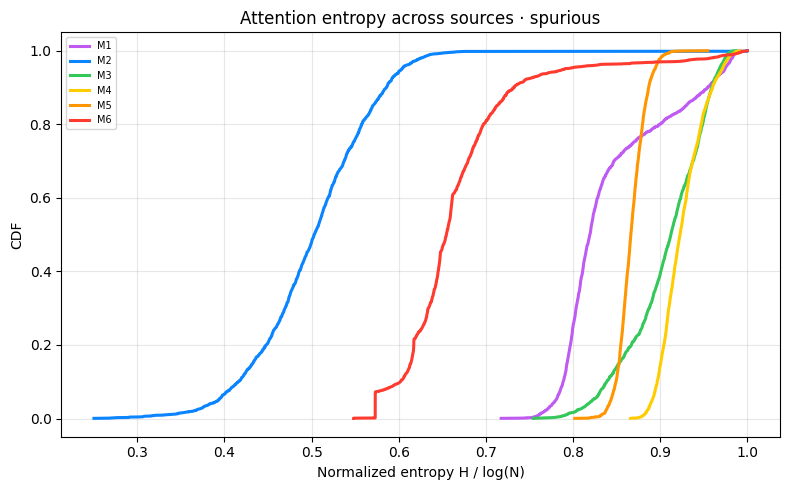

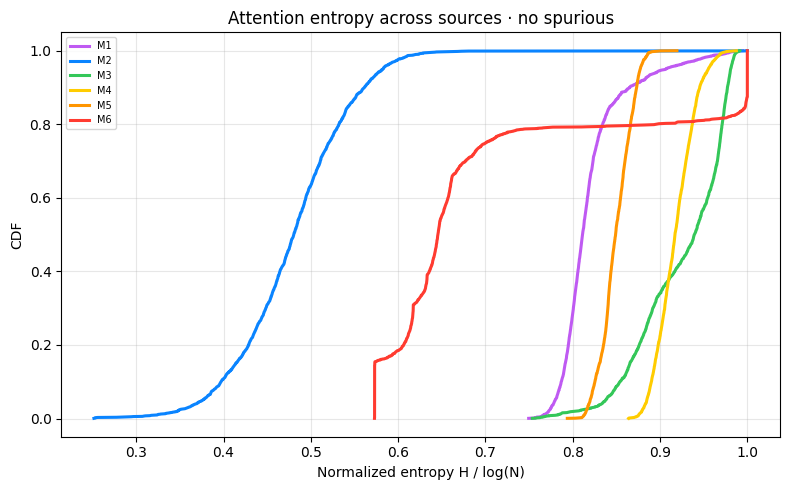

In [13]:
from collections import defaultdict


def plot_entropy(rows_subset, sp_label: str):
    by_arch = defaultdict(list)
    for r in rows_subset:
        by_arch[r["arch"]].append(r["entropy_norm"])

    fig, ax = plt.subplots(figsize=(8, 5))
    for arch in MODEL_ORDER_ARCH:
        vals = by_arch.get(arch, [])
        if not vals:
            continue
        x, y = cam.ecdf(np.asarray(vals, dtype=np.float64))
        if x.size:
            ax.plot(x, y, lw=2.2, color=MODEL_COLOR[arch], label=MODEL_SERIAL[arch])

    ax.set_xlabel("Normalized entropy H / log(N)")
    ax.set_ylabel("CDF")
    ax.set_title(f"Attention entropy across sources · {sp_label}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.show()


rows_sp = [r for r in rows if r["spurious"]]
rows_nosp = [r for r in rows if not r["spurious"]]

plot_entropy(rows_sp, "spurious")
plot_entropy(rows_nosp, "no spurious")

## 3. SSIM(CAM, 3σ radio mask)

Windowed SSIM (11×11, scipy `uniform_filter`) between **min–max normalized CAM** and **binary radio mask**. Single scalar per source; CDF per model group.

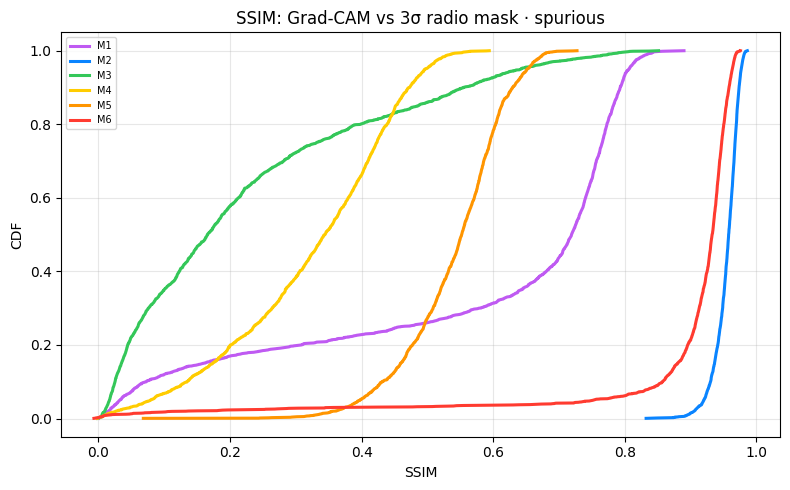

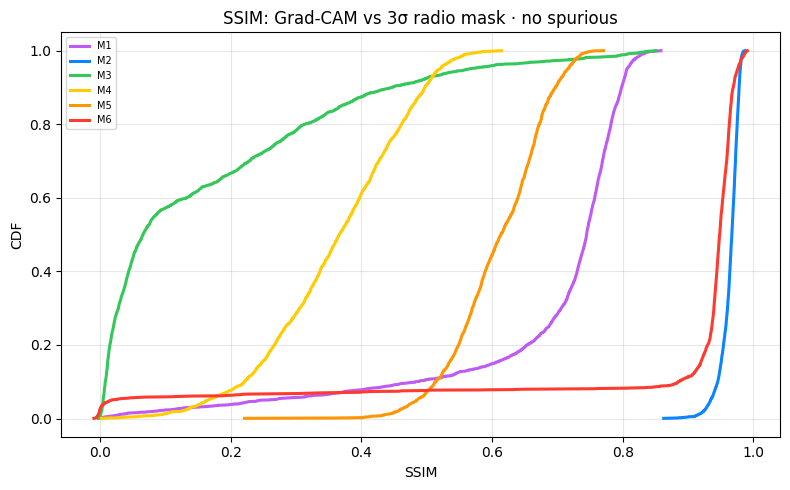

In [14]:
from collections import defaultdict


def plot_ssim(rows_subset, sp_label: str):
    by_arch = defaultdict(list)
    for r in rows_subset:
        by_arch[r["arch"]].append(r["ssim_hm_vs_radio_mask"])

    fig, ax = plt.subplots(figsize=(8, 5))
    for arch in MODEL_ORDER_ARCH:
        vals = by_arch.get(arch, [])
        if not vals:
            continue
        x, y = cam.ecdf(np.asarray(vals, dtype=np.float64))
        if x.size:
            ax.plot(x, y, lw=2.2, color=MODEL_COLOR[arch], label=MODEL_SERIAL[arch])

    ax.set_xlabel("SSIM")
    ax.set_ylabel("CDF")
    ax.set_title(f"SSIM: Grad-CAM vs 3σ radio mask · {sp_label}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.show()


rows_sp = [r for r in rows if r["spurious"]]
rows_nosp = [r for r in rows if not r["spurious"]]

plot_ssim(rows_sp, "spurious")
plot_ssim(rows_nosp, "no spurious")

## 4. Peak distance vs localization spread

- **Peak distance:** argmax of CAM vs center of mass of the 3σ mask, normalized by image diagonal.
- **Spread:** √(Var_x + Var_y) for coordinates weighted by **unnormalized** CAM (mass spread in pixels).

Each dot is one source; alpha shows overlap.

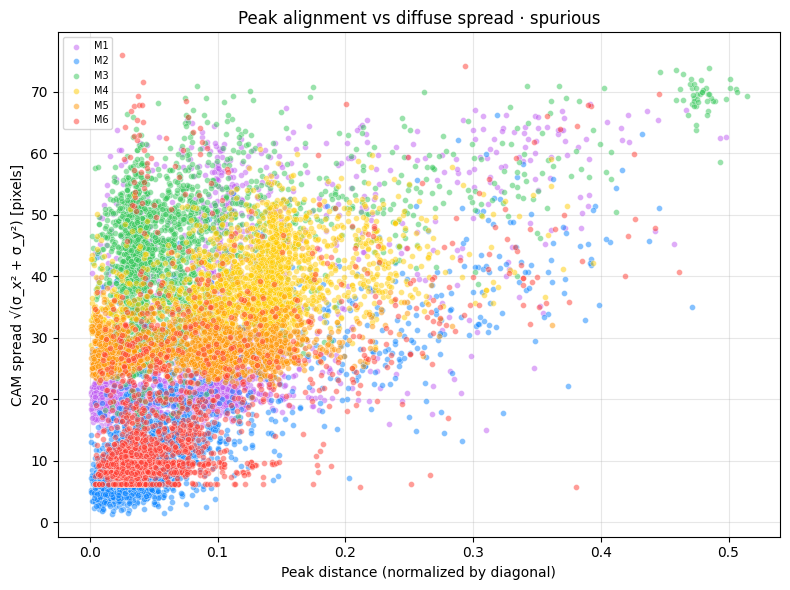

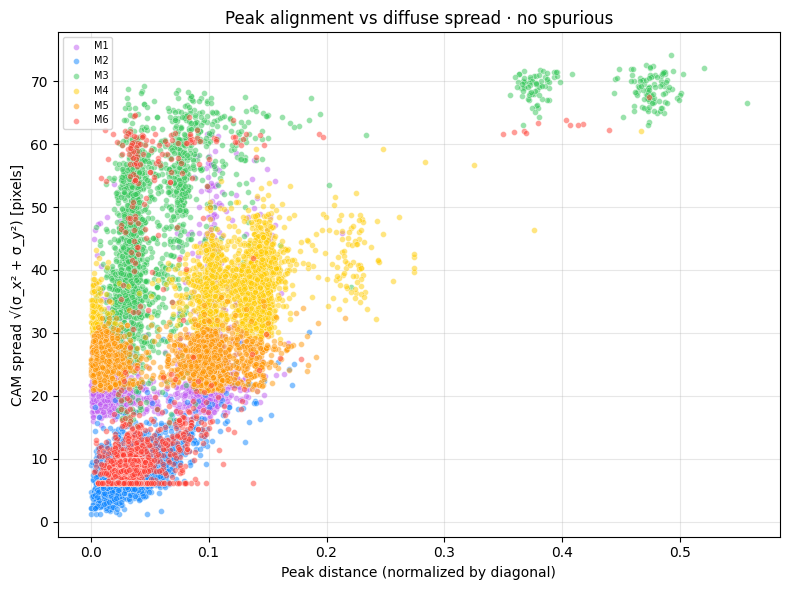

In [15]:
def plot_peak(rows_subset, sp_label: str):
    fig, ax = plt.subplots(figsize=(8, 6))

    for arch in MODEL_ORDER_ARCH:
        pts = [(r["peak_dist_norm"], r["spread_l2"]) for r in rows_subset if r["arch"] == arch]
        if not pts:
            continue

        xs = np.asarray([p[0] for p in pts], dtype=np.float64)
        ys = np.asarray([p[1] for p in pts], dtype=np.float64)
        m = np.isfinite(xs) & np.isfinite(ys)

        ax.scatter(
            xs[m],
            ys[m],
            s=18,
            alpha=0.50,
            color=MODEL_COLOR[arch],
            label=MODEL_SERIAL[arch],
            edgecolors="white",
            linewidths=0.4,
            zorder=3,
        )

    ax.set_xlabel("Peak distance (normalized by diagonal)")
    ax.set_ylabel("CAM spread √(σ_x² + σ_y²) [pixels]")
    ax.set_title(f"Peak alignment vs diffuse spread · {sp_label}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.show()


rows_sp = [r for r in rows if r["spurious"]]
rows_nosp = [r for r in rows if not r["spurious"]]

plot_peak(rows_sp, "spurious")
plot_peak(rows_nosp, "no spurious")

/tmp/ipykernel_850231/3419479735.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


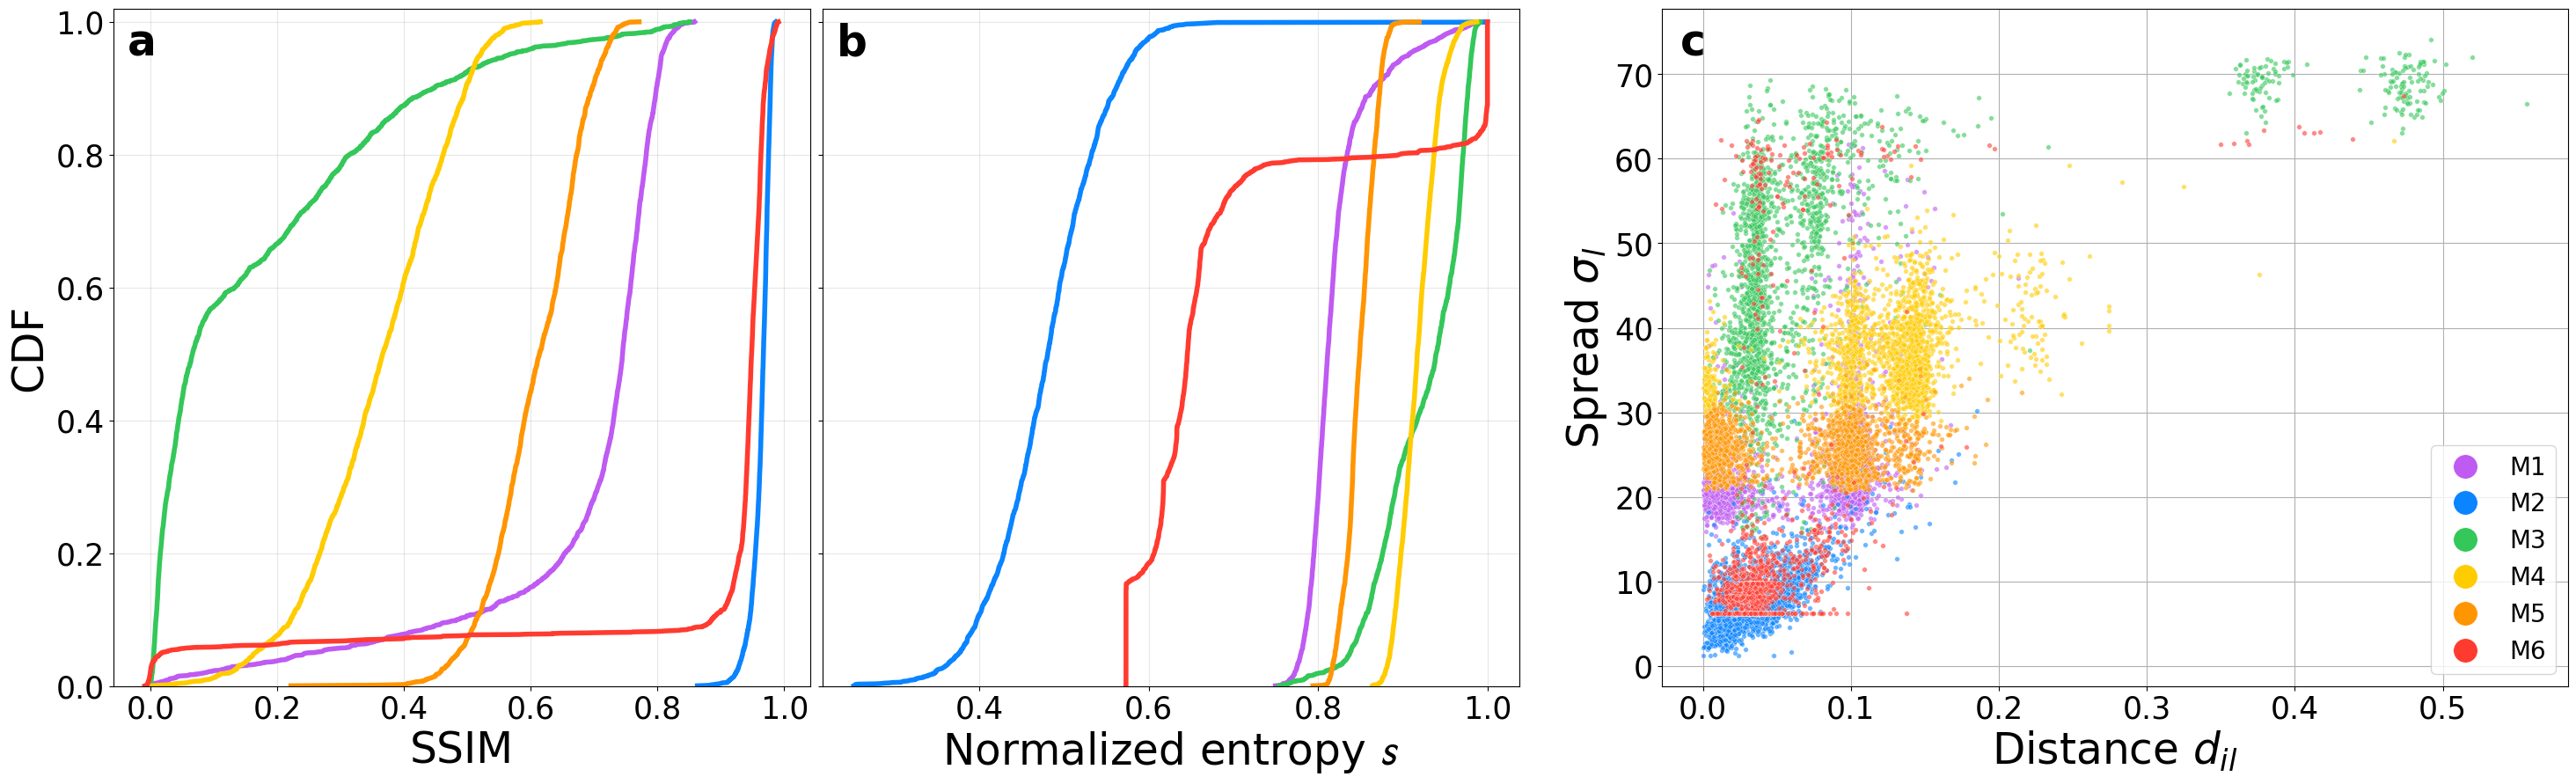

In [18]:
# Combined view (no-spurious only): panels a,b are CDFs with shared y-axis; panel c is distance vs spread
big_font = 35
medium_font = 25
small_font = 21
rows_nosp = [r for r in rows if not r["spurious"]]

fig = plt.figure(figsize=(30, 10))
# 4 columns: [a][b][gap][c] so a and b are attached; gap separates c
gs = fig.add_gridspec(nrows=1, ncols=4, width_ratios=[1, 1, 0.17, 1.3], wspace=0.02)

ax_ssim = fig.add_subplot(gs[0, 0])
ax_ent = fig.add_subplot(gs[0, 1], sharey=ax_ssim)
ax_sc_nosp = fig.add_subplot(gs[0, 3])


def _vals_for_arch(rows_subset, arch, key):
    return [r[key] for r in rows_subset if r["arch"] == arch]


# --- Panel a: SSIM CDF (no-spurious only) ---
for arch in MODEL_ORDER_ARCH:
    vals = np.asarray(_vals_for_arch(rows_nosp, arch, "ssim_hm_vs_radio_mask"), dtype=np.float64)
    if vals.size:
        x, y = cam.ecdf(vals)
        ax_ssim.plot(x, y, lw=4, color=MODEL_COLOR[arch], linestyle="-", label=MODEL_SERIAL[arch])

ax_ssim.set_xlabel("SSIM", fontsize=big_font    )
ax_ssim.set_ylabel("CDF", fontsize=big_font)
ax_ssim.tick_params(axis="both", which="major", labelsize=medium_font)
ax_ssim.set_ylim(0, 1.02)
ax_ssim.grid(True, alpha=0.3)
ax_ssim.text(0.02, 0.98, "a", transform=ax_ssim.transAxes, va="top", ha="left", fontsize=big_font, fontweight="bold")

# --- Panel b: Entropy CDF (no-spurious only) ---
for arch in MODEL_ORDER_ARCH:
    vals = np.asarray(_vals_for_arch(rows_nosp, arch, "entropy_norm"), dtype=np.float64)
    if vals.size:
        x, y = cam.ecdf(vals)
        ax_ent.plot(x, y, lw=4, color=MODEL_COLOR[arch], linestyle="-", label=MODEL_SERIAL[arch])

ax_ent.set_xlabel( r"Normalized entropy $\mathcal{s}$ ", fontsize=big_font)
ax_ent.set_ylabel("")
ax_ent.tick_params(axis="x", which="major", labelsize=medium_font)
ax_ent.tick_params(labelleft=False)
ax_ent.set_ylim(0, 1.02)
ax_ent.grid(True, alpha=0.3)
ax_ent.text(0.02, 0.98, "b", transform=ax_ent.transAxes, va="top", ha="left", fontsize=big_font, fontweight="bold")


# --- Panel c: Peak distance vs spread (no-spurious only) ---
for arch in MODEL_ORDER_ARCH:
    pts = [(r["peak_dist_norm"], r["spread_l2"]) for r in rows_nosp if r["arch"] == arch]
    if not pts:
        continue
    xs = np.asarray([p[0] for p in pts], dtype=np.float64)
    ys = np.asarray([p[1] for p in pts], dtype=np.float64)
    m = np.isfinite(xs) & np.isfinite(ys)

    ax_sc_nosp.scatter(
        xs[m],
        ys[m],
        s=16,
        alpha=0.6,
        color=MODEL_COLOR[arch],
        label=MODEL_SERIAL[arch],
        edgecolors="white",
        linewidths=0.35,
        zorder=3,
    )

ax_sc_nosp.set_xlabel(r"Distance $d_{il}$", fontsize=big_font)
ax_sc_nosp.set_ylabel(r"Spread $\sigma_{l}$", fontsize=big_font)
ax_sc_nosp.tick_params(axis="both", which="major", labelsize=medium_font)
ax_sc_nosp.grid(True, alpha=1)
ax_sc_nosp.text(0.02, 0.98, "c", transform=ax_sc_nosp.transAxes, va="top", ha="left", fontsize=big_font, fontweight="bold")

# Legend only on panel c (opaque markers)
from matplotlib.lines import Line2D

legend_handles = []
legend_labels = []
for arch in MODEL_ORDER_ARCH:
    if any(r["arch"] == arch for r in rows_nosp):
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="None",
                markersize=20,
                markerfacecolor=MODEL_COLOR[arch],
                markeredgecolor="white",
                markeredgewidth=0.6,
                alpha=1.0,
            )
        )
        legend_labels.append(MODEL_SERIAL[arch])

ax_sc_nosp.legend(legend_handles, legend_labels, loc="lower right", fontsize=20, frameon=True)

plt.subplots_adjust(left=0.05, right=0.98)
plt.tight_layout()
plt.savefig("peak_distance_vs_spread.pdf", dpi=300)
plt.show()


## Quick single-NPZ check (optional)

Uses the same resizing as metrics.

gray (150, 150) hm (150, 150)


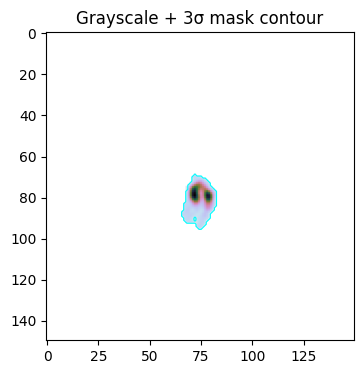

In [17]:
npz_path = os.path.join(
    BASE,
    "byol",
    "byol-no_spurious_fold_0",
    "grad_cam_without_sp",
    "cam_npz",
    "nat_L0024_001248.72-060652.7_masked.npz",
)
z = np.load(npz_path)
gray, hm = cam.load_gray_heatmap_150(z)
print("gray", gray.shape, "hm", hm.shape)
src = cam.radio_mask_sigma(gray, n_sigma=3.0)
plt.figure(figsize=(4, 4))
plt.imshow(gray, cmap="cubehelix_r")
plt.contour(src, levels=[0.5], colors="cyan", linewidths=0.8)
plt.title("Grayscale + 3σ mask contour")
plt.show()